In [3]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "Helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "Helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "Helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results folder: {OUT_DIR}")

Project root: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking
Results folder: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results


# R2 threshold experiment

This notebook estimates a robust Gaussian-fit \(R^2\) threshold for localization. It follows the same simple structure as the detection-threshold experiment:

1. simulate repeated movies with the shared `Simulator` class;
2. localize peaks with the existing `extract_peaks(..., mode="localization")` helper;
3. sweep the \(R^2\) threshold;
4. average detection/localization metrics over seeds;
5. plot the final recommendation panels at the end.

In [8]:
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import linear_sum_assignment

from Helpers.helpersSimulation import Simulator
from Helpers.helpersTracking import extract_peaks

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
})

## Experiment configuration

The detection threshold is fixed so the sweep isolates the effect of the Gaussian-fit \(R^2\) filter. The default value below matches the intensity configuration used here and is close to the detection-threshold notebook's selected operating point. The default sweep is intentionally compact enough to rerun during analysis; increase `N_SEEDS`, `nparticles`, or `nframes` for a heavier final validation run.

In [6]:
N_SEEDS = 3
SEEDS = list(range(N_SEEDS))

R2_THRESHOLDS = np.round(np.linspace(0.40, 0.70, 7), 3)
MATCH_TOLERANCE_PX = 3.0
FORCE_RERUN = True

D_LIST = [
    (0.10, 0.30),
    (0.50, 0.10),
    (1.50, 0.15),
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20),
]

SIMULATION_CONFIG = {
    "nparticles": 20,
    "nframes": 40,
    "nposframe": 5,
    "D_list": D_LIST,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 700,
    "intensity_std": 300,
}

IMAGE_CONFIG = {
    "particle_intensity": [700, 300],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
    "use_trajectory_sigma": True,
}

RESULT_STEM = f"R2Experiment_np{SIMULATION_CONFIG['nparticles']}_nf{SIMULATION_CONFIG['nframes']}_npf{SIMULATION_CONFIG['nposframe']}"
RESULT_PATHS = {
    "results": OUT_DIR / f"{RESULT_STEM}_results.csv",
    "summary": OUT_DIR / f"{RESULT_STEM}_summary.csv",
    "figure_png": OUT_DIR / f"{RESULT_STEM}_summary.png",
    "figure_pdf": OUT_DIR / f"{RESULT_STEM}_summary.pdf",
}

print(f"Seeds: {SEEDS}")
print(f"R2 thresholds: {R2_THRESHOLDS[0]:.2f} to {R2_THRESHOLDS[-1]:.2f} ({len(R2_THRESHOLDS)} values)")

Seeds: [0, 1, 2]
R2 thresholds: 0.40 to 0.70 (7 values)


## Metric helpers

In [7]:
def finite_mean(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(values.mean()) if len(values) else np.nan


def finite_median(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.median(values)) if len(values) else np.nan


def finite_sem(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) <= 1:
        return np.nan
    return float(values.std(ddof=1) / np.sqrt(len(values)))


def positions_by_frame_from_gt(trajectories_gt, nframes, frame_size):
    height, width = frame_size
    by_frame = [[] for _ in range(nframes)]

    for traj in trajectories_gt:
        for frame in traj.frames():
            if frame < 0 or frame >= nframes:
                continue
            pos = traj.get_position_at_frame(frame)
            if pos is None:
                continue
            row, col = map(float, pos)
            if 0 <= row < height and 0 <= col < width:
                by_frame[int(frame)].append(np.asarray([row, col], dtype=float))

    return by_frame


def positions_by_frame_from_peaks(localized_peaks, nframes):
    by_frame = [[] for _ in range(nframes)]
    r2_values = []
    sigma_values = []
    intensity_values = []

    for frame_idx, frame_peaks in enumerate(localized_peaks[:nframes]):
        for peak in frame_peaks:
            pos = peak[0]
            by_frame[frame_idx].append(np.asarray(pos, dtype=float))
            if len(peak) > 1:
                intensity_values.append(float(peak[1]))
            if len(peak) > 2:
                sigma_values.append(float(peak[2]))
            if len(peak) > 3:
                r2_values.append(float(peak[3]))

    return by_frame, np.asarray(r2_values), np.asarray(sigma_values), np.asarray(intensity_values)


def match_frame(pred_positions, gt_positions, tolerance_px):
    if len(pred_positions) == 0 or len(gt_positions) == 0:
        return 0, len(pred_positions), len(gt_positions), []

    cost = np.empty((len(pred_positions), len(gt_positions)), dtype=float)
    for i, pred in enumerate(pred_positions):
        for j, gt in enumerate(gt_positions):
            cost[i, j] = float(np.linalg.norm(pred - gt))

    row_ind, col_ind = linear_sum_assignment(cost)
    matched_errors = [
        float(cost[i, j])
        for i, j in zip(row_ind, col_ind)
        if cost[i, j] <= tolerance_px
    ]
    tp = len(matched_errors)
    fp = len(pred_positions) - tp
    fn = len(gt_positions) - tp
    return tp, fp, fn, matched_errors


def evaluate_localizations(localized_peaks, trajectories_gt, sim_cfg, tolerance_px=MATCH_TOLERANCE_PX):
    nframes = int(sim_cfg["nframes"])
    gt_by_frame = positions_by_frame_from_gt(
        trajectories_gt,
        nframes=nframes,
        frame_size=sim_cfg["frame_size"],
    )
    pred_by_frame, r2_values, sigma_values, intensity_values = positions_by_frame_from_peaks(
        localized_peaks,
        nframes=nframes,
    )

    frame_rows = []
    all_errors = []
    tp_total = fp_total = fn_total = 0

    for frame_idx, (pred_positions, gt_positions) in enumerate(zip(pred_by_frame, gt_by_frame)):
        tp, fp, fn, errors = match_frame(pred_positions, gt_positions, tolerance_px)
        tp_total += tp
        fp_total += fp
        fn_total += fn
        all_errors.extend(errors)
        frame_rows.append({
            "frame": frame_idx,
            "n_pred": len(pred_positions),
            "n_gt": len(gt_positions),
            "abs_count_error": abs(len(pred_positions) - len(gt_positions)),
            "squared_count_error": (len(pred_positions) - len(gt_positions)) ** 2,
        })

    precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else np.nan
    recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
        else np.nan
    )

    frame_df = pd.DataFrame(frame_rows)
    gt_total = int(frame_df["n_gt"].sum())
    pred_total = int(frame_df["n_pred"].sum())

    return {
        "gt_total": gt_total,
        "localized_total": pred_total,
        "mean_gt_per_frame": float(frame_df["n_gt"].mean()),
        "mean_localized_per_frame": float(frame_df["n_pred"].mean()),
        "mean_abs_count_error_per_frame": float(frame_df["abs_count_error"].mean()),
        "rmse_count_per_frame": float(np.sqrt(frame_df["squared_count_error"].mean())),
        "tp": int(tp_total),
        "fp": int(fp_total),
        "fn": int(fn_total),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_position_error_px": finite_mean(all_errors),
        "median_position_error_px": finite_median(all_errors),
        "mean_kept_r2": finite_mean(r2_values),
        "mean_kept_sigma_px": finite_mean(sigma_values),
        "mean_kept_intensity": finite_mean(intensity_values),
    }

## Sweep runner

In [8]:
def make_simulation(seed):
    return Simulator(
        simulation_config=copy.deepcopy(SIMULATION_CONFIG),
        image_config=copy.deepcopy(IMAGE_CONFIG),
        seed=seed,
    ).run()


def run_one_seed(seed, r2_thresholds=R2_THRESHOLDS, verbose=True):
    sim = make_simulation(seed)
    rows = []

    for r2_threshold in r2_thresholds:
        t0 = time.perf_counter()
        localized_peaks = extract_peaks(
            sim.frames,
            mode="localization",
            detection_threshold=None,
            r_squared_threshold=float(r2_threshold),
            verbose_loc=False,
            visualization_loc=False,
        )
        runtime_s = time.perf_counter() - t0

        row = evaluate_localizations(
            localized_peaks,
            sim.trajectories_GT,
            SIMULATION_CONFIG,
            tolerance_px=MATCH_TOLERANCE_PX,
        )
        row.update({
            "seed": seed,
            "r2_threshold": float(r2_threshold),
            "runtime_s": runtime_s,
        })
        rows.append(row)

    if verbose:
        print(f"seed={seed}: evaluated {len(r2_thresholds)} thresholds")

    return rows


def summarize_results(results_df):
    metric_cols = [
        "localized_total",
        "mean_localized_per_frame",
        "mean_abs_count_error_per_frame",
        "rmse_count_per_frame",
        "precision",
        "recall",
        "f1",
        "mean_position_error_px",
        "median_position_error_px",
        "mean_kept_r2",
        "mean_kept_sigma_px",
        "runtime_s",
    ]

    rows = []
    for r2_threshold, group in results_df.groupby("r2_threshold", sort=True):
        row = {
            "r2_threshold": float(r2_threshold),
            "n": int(len(group)),
            "gt_total_mean": finite_mean(group["gt_total"]),
            "mean_gt_per_frame": finite_mean(group["mean_gt_per_frame"]),
        }
        for metric in metric_cols:
            values = group[metric].to_numpy(dtype=float)
            row[f"{metric}_mean"] = finite_mean(values)
            row[f"{metric}_ci95"] = 1.96 * finite_sem(values)
        rows.append(row)

    return pd.DataFrame(rows)


def choose_best_threshold(summary_df, f1_tolerance=0.005):
    """Pick the highest R2 on the top-F1 plateau.

    Any threshold with mean F1 within f1_tolerance of the best observed
    value is considered equivalent performance; among those, prefer the
    highest R2 to keep only stronger Gaussian fits.
    """
    max_f1 = float(summary_df["f1_mean"].max())
    candidates = summary_df[summary_df["f1_mean"] >= max_f1 - f1_tolerance].copy()

    # Resolve ties by favoring stricter (higher) R2, then better secondary metrics.
    ranked = candidates.sort_values(
        ["r2_threshold", "mean_abs_count_error_per_frame_mean", "mean_position_error_px_mean"],
        ascending=[False, True, True],
    )

    full_ranking = summary_df.sort_values(
        ["f1_mean", "r2_threshold", "mean_abs_count_error_per_frame_mean", "mean_position_error_px_mean"],
        ascending=[False, False, True, True],
    )

    return float(ranked.iloc[0]["r2_threshold"]), full_ranking


def run_experiment(seeds=SEEDS, force_rerun=FORCE_RERUN, verbose=True):
    if RESULT_PATHS["results"].exists() and not force_rerun:
        results_df = pd.read_csv(RESULT_PATHS["results"])
        summary_df = summarize_results(results_df)
        print("Loaded cached R2 experiment results.")
        return results_df, summary_df

    rows = []
    for seed in seeds:
        rows.extend(run_one_seed(seed, verbose=verbose))

    results_df = pd.DataFrame(rows)
    summary_df = summarize_results(results_df)

    results_df.to_csv(RESULT_PATHS["results"], index=False)
    summary_df.to_csv(RESULT_PATHS["summary"], index=False)
    print("Saved new R2 experiment results.")

    return results_df, summary_df

## Run or load results

In [9]:
results_df, summary_df = run_experiment()
best_r2, ranked_summary = choose_best_threshold(summary_df)
summary_df.to_csv(RESULT_PATHS["summary"], index=False)

print(f"Best R2 threshold by mean F1: {best_r2:.2f}")
display(ranked_summary[[
    "r2_threshold",
    "n",
    "f1_mean",
    "f1_ci95",
    "precision_mean",
    "recall_mean",
    "mean_abs_count_error_per_frame_mean",
    "mean_position_error_px_mean",
]])

seed=0: evaluated 7 thresholds
seed=1: evaluated 7 thresholds
seed=2: evaluated 7 thresholds
Saved new R2 experiment results.
Best R2 threshold by mean F1: 0.60


,r2_threshold,n,f1_mean,f1_ci95,precision_mean,recall_mean,mean_abs_count_error_per_frame_mean,mean_position_error_px_mean
0,0.40,3,0.886221,0.035557,0.886091,0.886449,1.158333,0.926576
1,0.45,3,0.885675,0.035476,0.886708,0.884753,1.141667,0.927103
2,0.50,3,0.884870,0.036319,0.887206,0.882653,1.150000,0.924041
4,0.60,3,0.883993,0.030887,0.897064,0.871348,1.266667,0.918408
3,0.55,3,0.883490,0.036096,0.891651,0.875516,1.191667,0.920734
5,0.65,3,0.881214,0.029257,0.904084,0.859565,1.425000,0.913090
6,0.70,3,0.879513,0.036647,0.918414,0.843990,1.841667,0.903545


## Final summary panels

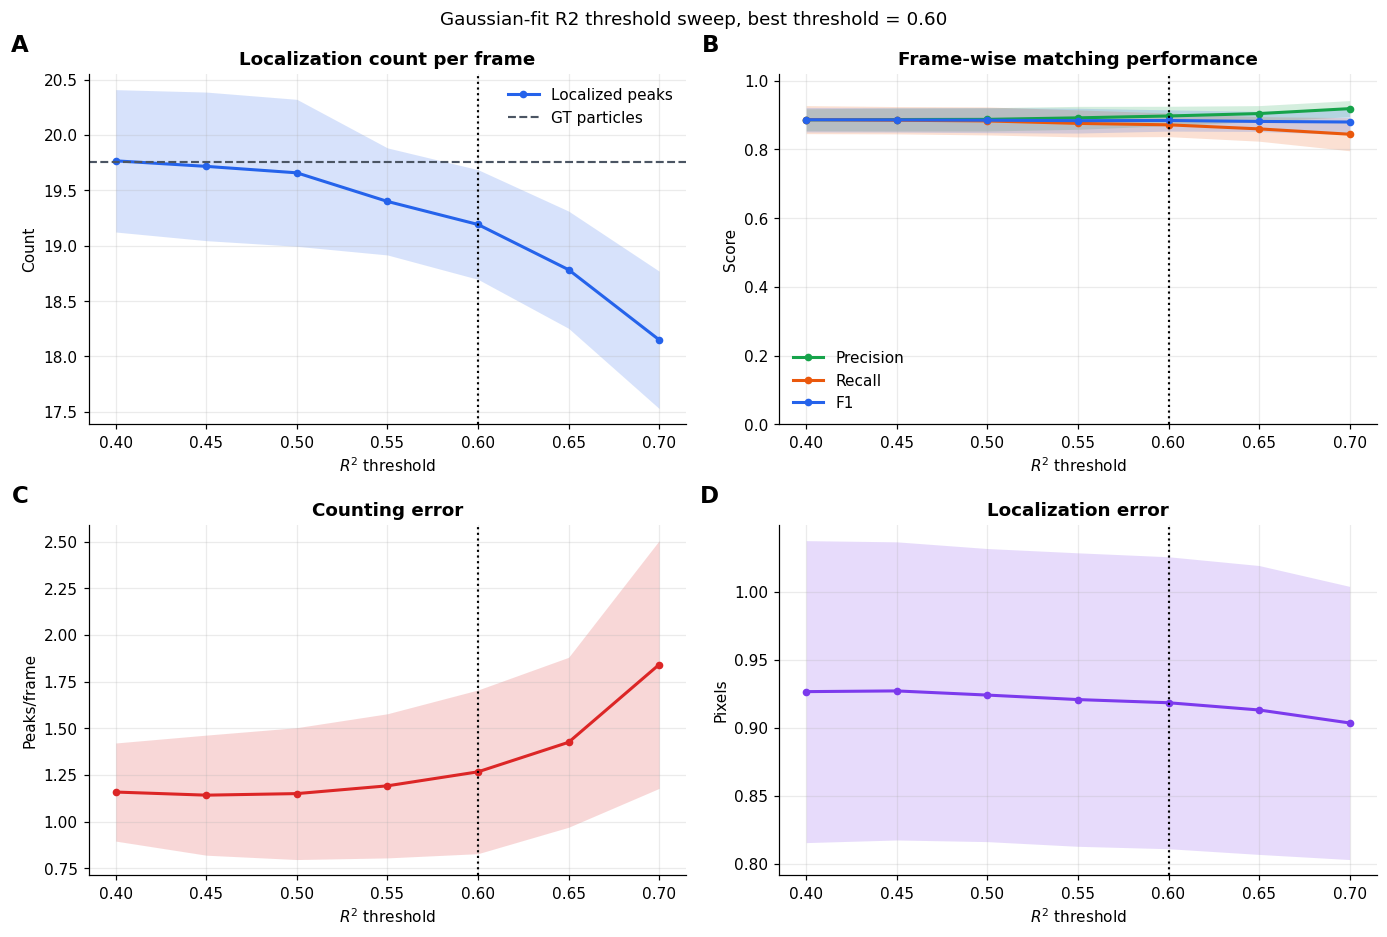

Saved final panels:
- C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results\R2Experiment_np20_nf40_npf5_summary.png
- C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results\R2Experiment_np20_nf40_npf5_summary.pdf


In [10]:
def add_panel_label(ax, label):
    ax.text(
        -0.10,
        1.05,
        label,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="bottom",
        ha="right",
    )


def plot_mean_with_ci(ax, x, mean, ci95, label, color, marker="o"):
    yerr = np.nan_to_num(ci95, nan=0.0)
    ax.plot(x, mean, marker=marker, linewidth=2, markersize=4, label=label, color=color)
    ax.fill_between(x, mean - yerr, mean + yerr, color=color, alpha=0.18, linewidth=0)


x = summary_df["r2_threshold"].to_numpy(dtype=float)
colors = {
    "blue": "#2563eb",
    "green": "#16a34a",
    "red": "#dc2626",
    "orange": "#ea580c",
    "purple": "#7c3aed",
    "gray": "#4b5563",
}

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.2), constrained_layout=True)
axes = axes.ravel()

plot_mean_with_ci(
    axes[0],
    x,
    summary_df["mean_localized_per_frame_mean"].to_numpy(dtype=float),
    summary_df["mean_localized_per_frame_ci95"].to_numpy(dtype=float),
    "Localized peaks",
    colors["blue"],
)
gt_ref = float(summary_df["mean_gt_per_frame"].mean())
axes[0].axhline(gt_ref, color=colors["gray"], linestyle="--", linewidth=1.4, label="GT particles")
axes[0].set_title("Localization count per frame")
axes[0].set_ylabel("Count")
axes[0].legend(frameon=False)

for metric, label, color in [
    ("precision", "Precision", colors["green"]),
    ("recall", "Recall", colors["orange"]),
    ("f1", "F1", colors["blue"]),
]:
    plot_mean_with_ci(
        axes[1],
        x,
        summary_df[f"{metric}_mean"].to_numpy(dtype=float),
        summary_df[f"{metric}_ci95"].to_numpy(dtype=float),
        label,
        color,
    )
axes[1].set_ylim(0, 1.02)
axes[1].set_title("Frame-wise matching performance")
axes[1].set_ylabel("Score")
axes[1].legend(frameon=False)

plot_mean_with_ci(
    axes[2],
    x,
    summary_df["mean_abs_count_error_per_frame_mean"].to_numpy(dtype=float),
    summary_df["mean_abs_count_error_per_frame_ci95"].to_numpy(dtype=float),
    "Mean absolute count error",
    colors["red"],
)
axes[2].set_title("Counting error")
axes[2].set_ylabel("Peaks/frame")

plot_mean_with_ci(
    axes[3],
    x,
    summary_df["mean_position_error_px_mean"].to_numpy(dtype=float),
    summary_df["mean_position_error_px_ci95"].to_numpy(dtype=float),
    "Matched localization error",
    colors["purple"],
)
axes[3].set_title("Localization error")
axes[3].set_ylabel("Pixels")

for label, ax in zip("ABCD", axes):
    add_panel_label(ax, label)
    ax.axvline(best_r2, color="black", linestyle=":", linewidth=1.4)
    ax.set_xlabel("$R^2$ threshold")
    ax.grid(alpha=0.25)

fig.suptitle(f"Gaussian-fit R2 threshold sweep, best threshold = {best_r2:.2f}", y=1.02)
fig.savefig(RESULT_PATHS["figure_png"], bbox_inches="tight")
fig.savefig(RESULT_PATHS["figure_pdf"], bbox_inches="tight")
plt.show()

print("Saved final panels:")
print(f"- {RESULT_PATHS['figure_png']}")
print(f"- {RESULT_PATHS['figure_pdf']}")

## $R^2$ tuning on real data

In [4]:
import tifffile as tiff
import numpy as np
from pathlib import Path

# Path to the TIFF relative to your script
tif_path = PROJECT_ROOT / "Data" / "frames_104.tif"
tif_path2 = PROJECT_ROOT / "Data" / "frames2_104.tif"


# Load the two full TIFF stack (1000 frames)
frames_full = tiff.imread(tif_path)
frames2_full = tiff.imread(tif_path2)

# Ensure float32 dtype (your simulated pipeline uses float32)
frames_full = frames_full.astype(np.float32)
frames2_full = frames2_full.astype(np.float32)

print("Loaded frames:", frames_full.shape, frames_full.dtype)

Loaded frames: (1000, 128, 128) float32


In [5]:
# extract 10 stacks of 100 frames each to repeat the experiment
frames_stacks = []
for start in range(0, 1000, 100):
    end = start + 100
    if end <= frames_full.shape[0]:
        frames_stacks.append(frames_full[start:end])

In [6]:
# define range of R2 thresholds to test
r2_thresholds = np.linspace(0.2, 0.8, 11)

In [ ]:
# for each stack, run the localization with the range of R2 threshold and plot the number of localized peaks per frame for each threshold
for stack_idx, frames in enumerate(frames_stacks):
    localized_counts = []
    for r2_threshold in r2_thresholds:
        localized_peaks = extract_peaks(
            frames,
            mode="localization",
            detection_threshold=2000,
            r_squared_threshold=float(r2_threshold),
            verbose_loc=False,
            visualization_loc=False,
        )
        counts_per_frame = [len(frame_peaks) for frame_peaks in localized_peaks[:frames.shape[0]]]
        localized_counts.append(counts_per_frame)

    plt.figure(figsize=(10, 6))
    for idx, counts in enumerate(localized_counts):
        plt.plot(counts, label=f"R2={r2_thresholds[idx]:.2f}")
    plt.title(f"Localized peaks per frame for stack {stack_idx}")
    plt.xlabel("Frame")
    plt.ylabel("Localized peaks")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Processing stack 0/3


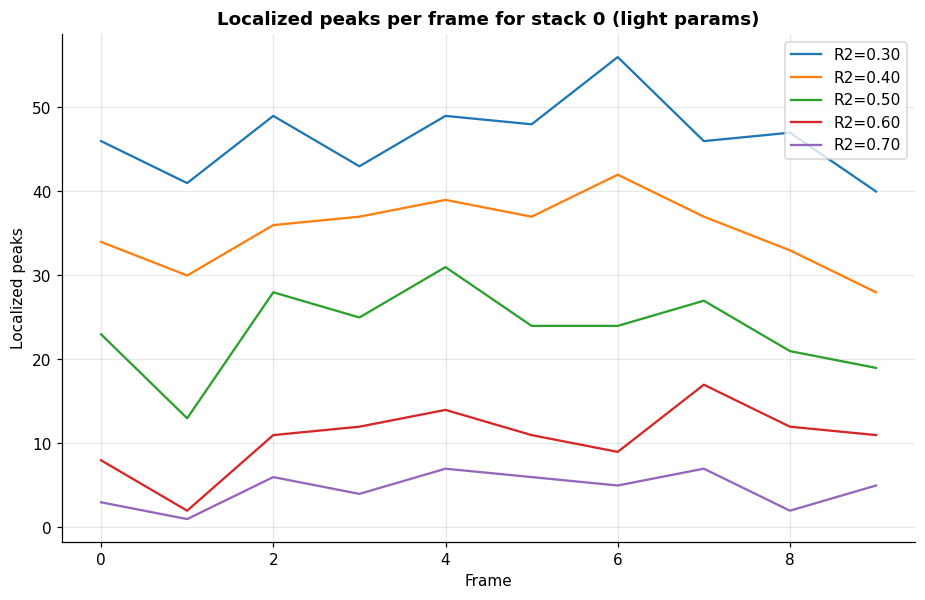

Processing stack 1/3


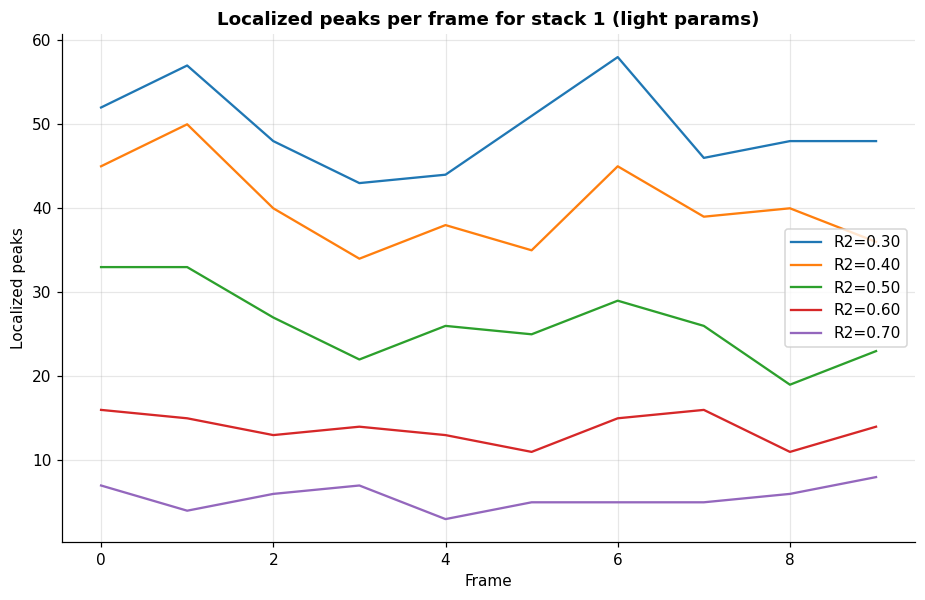

Processing stack 2/3


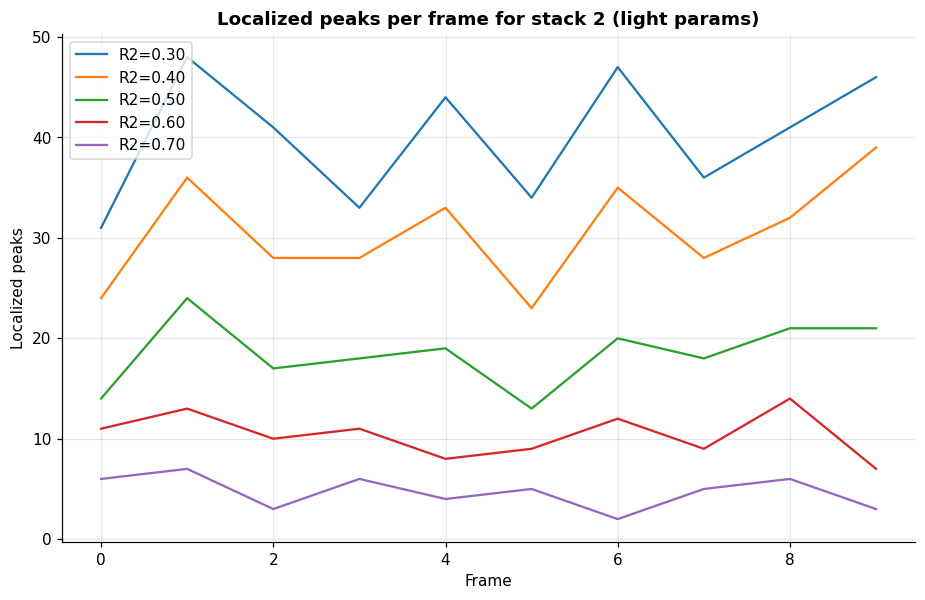

In [10]:
# first try with light params: cut all stacks to 10 frames only, use 3 stacks, and test only 5 R2 thresholds from 0.3 to 0.7
frames_stacks_light = [stack[:10] for stack in frames_stacks[:3]]
r2_thresholds_light = np.linspace(0.3, 0.7, 5)

for stack_idx, frames in enumerate(frames_stacks_light):
    print(f"Processing stack {stack_idx+1}/{len(frames_stacks_light)}")
    localized_counts = []
    for r2_threshold in r2_thresholds_light:
        localized_peaks = extract_peaks(
            frames,
            mode="localization",
            detection_threshold=2000,
            r_squared_threshold=float(r2_threshold),
            verbose_loc=False,
            visualization_loc=False,
        )
        counts_per_frame = [len(frame_peaks) for frame_peaks in localized_peaks[:frames.shape[0]]]
        localized_counts.append(counts_per_frame)

    plt.figure(figsize=(10, 6))
    for idx, counts in enumerate(localized_counts):
        plt.plot(counts, label=f"R2={r2_thresholds_light[idx]:.2f}")
    plt.title(f"Localized peaks per frame for stack {stack_idx} (light params)")
    plt.xlabel("Frame")
    plt.ylabel("Localized peaks")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()